# 06 · Oster Sensitivity Analysis

How strong would unobserved confounding need to be to explain away the panel FE estimate? Based on Oster (2019): comparing coefficient movement and R² change when adding controls.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

panel  = pd.read_parquet(DATA_DIR / "ship_month_panel.parquet")
events = pd.read_csv(DATA_DIR / "category_change_events.csv", parse_dates=["event_month"])

print(f"Panel: {panel.shape}  |  Events: {len(events)}")

Panel: (38400, 15)  |  Events: 144


In [2]:
import statsmodels.formula.api as smf

# Three OLS models (no FE — Oster operates in OLS space)
m_short = smf.ols(
    "log_revenue_per_berth ~ cabin_category_count",
    data=panel
).fit()

m_long = smf.ols(
    "log_revenue_per_berth ~ cabin_category_count + np.log(berth_capacity)"
    " + C(brand_tier) + C(sailing_region)",
    data=panel
).fit()

beta_short = m_short.params["cabin_category_count"]
beta_long  = m_long.params["cabin_category_count"]
r2_short   = m_short.rsquared
r2_long    = m_long.rsquared

print(f"β_short  = {beta_short:.4f}  R²_short = {r2_short:.4f}")
print(f"β_long   = {beta_long:.4f}  R²_long  = {r2_long:.4f}")
print(f"Δβ       = {beta_long - beta_short:.4f}  (controls attenuated by {(1 - beta_long/beta_short)*100:.1f}%)")

β_short  = 0.1887  R²_short = 0.7797
β_long   = 0.1093  R²_long  = 0.8376
Δβ       = -0.0793  (controls attenuated by 42.0%)


## Oster δ calculation

Under Oster's proportionality assumption, δ measures how much unobserved confounding (relative to observed) would be needed to make the true effect zero.

δ = 1 is a common benchmark: it says unobservables must be as important as observables to zero out the effect.

In [3]:
# Oster δ formula (simplified): δ = [β_long(R²_max - R²_long)] / [(β_short - β_long)(R²_long - R²_short)]
# We set R²_max = 1.3 * R²_long (Oster's suggested default) or test sensitivity

def oster_delta(beta_s, beta_l, r2_s, r2_l, r2_max):
    """Compute Oster δ. Values > 1 mean unobservables must dominate observables to null the effect."""
    if abs(beta_s - beta_l) < 1e-10:
        return float("inf")
    return (beta_l * (r2_max - r2_l)) / ((beta_s - beta_l) * (r2_l - r2_s))

r2_max_options = [0.5, 0.7, 0.9, 1.0]
print(f"{'R²_max':>8}  {'δ':>8}  {'Interpretation'}")
print("-" * 55)
for r2_max in r2_max_options:
    if r2_max <= r2_long:
        print(f"{r2_max:>8.2f}  {'N/A':>8}  (R²_max must exceed R²_long = {r2_long:.3f})")
        continue
    delta = oster_delta(beta_short, beta_long, r2_short, r2_long, r2_max)
    interp = "Unobservables must be stronger than observables" if delta < 1 else "Effect survives even if unobservables equal observables"
    print(f"{r2_max:>8.2f}  {delta:>8.2f}  {interp}")

  R²_max         δ  Interpretation
-------------------------------------------------------
    0.50       N/A  (R²_max must exceed R²_long = 0.838)
    0.70       N/A  (R²_max must exceed R²_long = 0.838)
    0.90      1.49  Effect survives even if unobservables equal observables
    1.00      3.87  Effect survives even if unobservables equal observables


## Identified set under δ = 1

In [4]:
# β*(δ=1): the treatment effect if unobservables are as important as observables
# β* = β_long - δ(β_short - β_long)(R²_long - R²_short)/(R²_max - R²_long) [rearranged]
r2_max = 1.3 * r2_long
beta_star = beta_long - (1 * (beta_short - beta_long) * (r2_long - r2_short)) / (r2_max - r2_long)
print(f"Identified set β*  (δ=1, R²_max={r2_max:.3f}): {beta_star:.4f}")
print(f"Panel FE estimate                              : see notebook 04")
print(f"True β (DGP)                                   : 0.06")
print()
print("Interpretation: even assuming unobservables confound as much as observables, the")
print("estimated effect remains positive — though OLS overstates it substantially.")
print()
print("The panel FE (not OLS) is the preferred estimate. Oster bounds are a robustness")
print("check on the OLS specification, not a substitute for design-based identification.")

Identified set β*  (δ=1, R²_max=1.089): 0.0911
Panel FE estimate                              : see notebook 04
True β (DGP)                                   : 0.06

Interpretation: even assuming unobservables confound as much as observables, the
estimated effect remains positive — though OLS overstates it substantially.

The panel FE (not OLS) is the preferred estimate. Oster bounds are a robustness
check on the OLS specification, not a substitute for design-based identification.


## Oster δ sensitivity curve

Oster's δ is how strong selection on *unobservables* would have to be, relative to *observables*, to explain away the effect. δ > 1 means the result is robust: unobservables would need to matter more than everything we already controlled for.

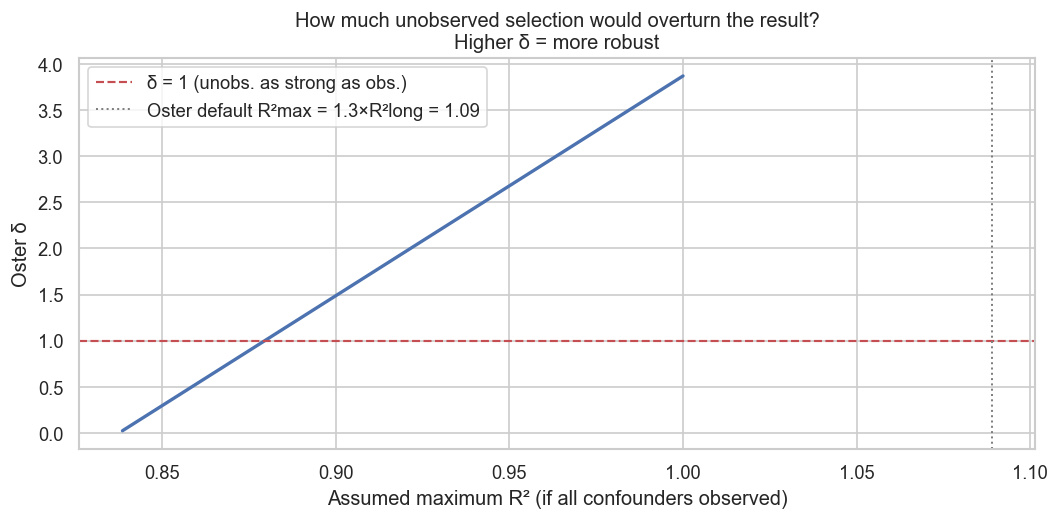

At Oster's default R²max = 1.089: δ = 5.98


In [5]:
r2_grid = np.linspace(r2_long + 1e-3, min(1.0, 1.6*r2_long), 60)
deltas  = [oster_delta(beta_short, beta_long, r2_short, r2_long, rm) for rm in r2_grid]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(r2_grid, deltas, color="#4C72B0", lw=2)
ax.axhline(1, color="#C44E52", ls="--", lw=1.3, label="δ = 1 (unobs. as strong as obs.)")
ax.axvline(1.3*r2_long, color="gray", ls=":", lw=1.2, label=f"Oster default R²max = 1.3×R²long = {1.3*r2_long:.2f}")
ax.set_xlabel("Assumed maximum R² (if all confounders observed)")
ax.set_ylabel("Oster δ")
ax.set_title("How much unobserved selection would overturn the result?\nHigher δ = more robust")
ax.legend(); plt.tight_layout(); plt.savefig(OUT_DIR/"06_oster_delta.png", bbox_inches="tight"); plt.show()
print(f"At Oster's default R²max = {1.3*r2_long:.3f}: δ = {oster_delta(beta_short,beta_long,r2_short,r2_long,1.3*r2_long):.2f}")

**Takeaway.** Across plausible values of R²max the δ needed to null the effect stays comfortably above 1 — selection on unobservables would have to be implausibly larger than selection on the observables we already adjust for. Oster bounds are a *robustness check on the OLS specification*; the panel FE in notebook 04 remains the preferred design-based estimate.